## Paper plots: Inverse Problems

## Setup

In [1]:
import torch
import numpy as np
import os

In [2]:
ROOT = "."
assert os.path.isfile(ROOT+"/inverse_problems.ipynb")

In [3]:
from matplotlib import pyplot,colors,cm,cycler
import pandas as pd
pyplot.style.use('seaborn-v0_8-whitegrid')
COLORS = ["xkcd:"+color[:-1] for color in pd.read_csv(ROOT+"/../../chonknoris/xkcd_colors.txt",comment="#",header=None).iloc[:,0].tolist()][::-1]
pyplot.rcParams['axes.prop_cycle'] = cycler(color=COLORS)
import matplotlib
matplotlib.rcParams['xtick.labelsize'] = 12
matplotlib.rcParams['ytick.labelsize'] = 12 
lwthick = 5
lwthin = .5
alpha = .25
alpha2 = .1
cmap = pyplot.cm.gnuplot2
linestyles = ["solid","dashed","dotted","dashdot"]

## Full Figure

In [4]:
ds_si = torch.load("in/data_final_plot.seismic_imaging.pt",weights_only=True)
ds_si_ref = ds_si["data_ref"]
ds_si_chonknoris = ds_si["data_chonknoris"]
r_si = 3
vs_chonknoris = ds_si["vs"][r_si]
vs_l2rerrors = ds_si["vs_l2rerrors"][r_si]
print(ds_si_ref["metrics"])
print(ds_si_chonknoris["metrics"])
print("vs_chonknoris.shape = %s"%str(tuple(vs_chonknoris.shape)))
print("vs_l2rerrors.shape = %s"%str(tuple(vs_l2rerrors.shape)))

['cond_nums', 'l2rerrors']
['l2rerrors']
vs_chonknoris.shape = (2501, 7, 7)
vs_l2rerrors.shape = (2501,)


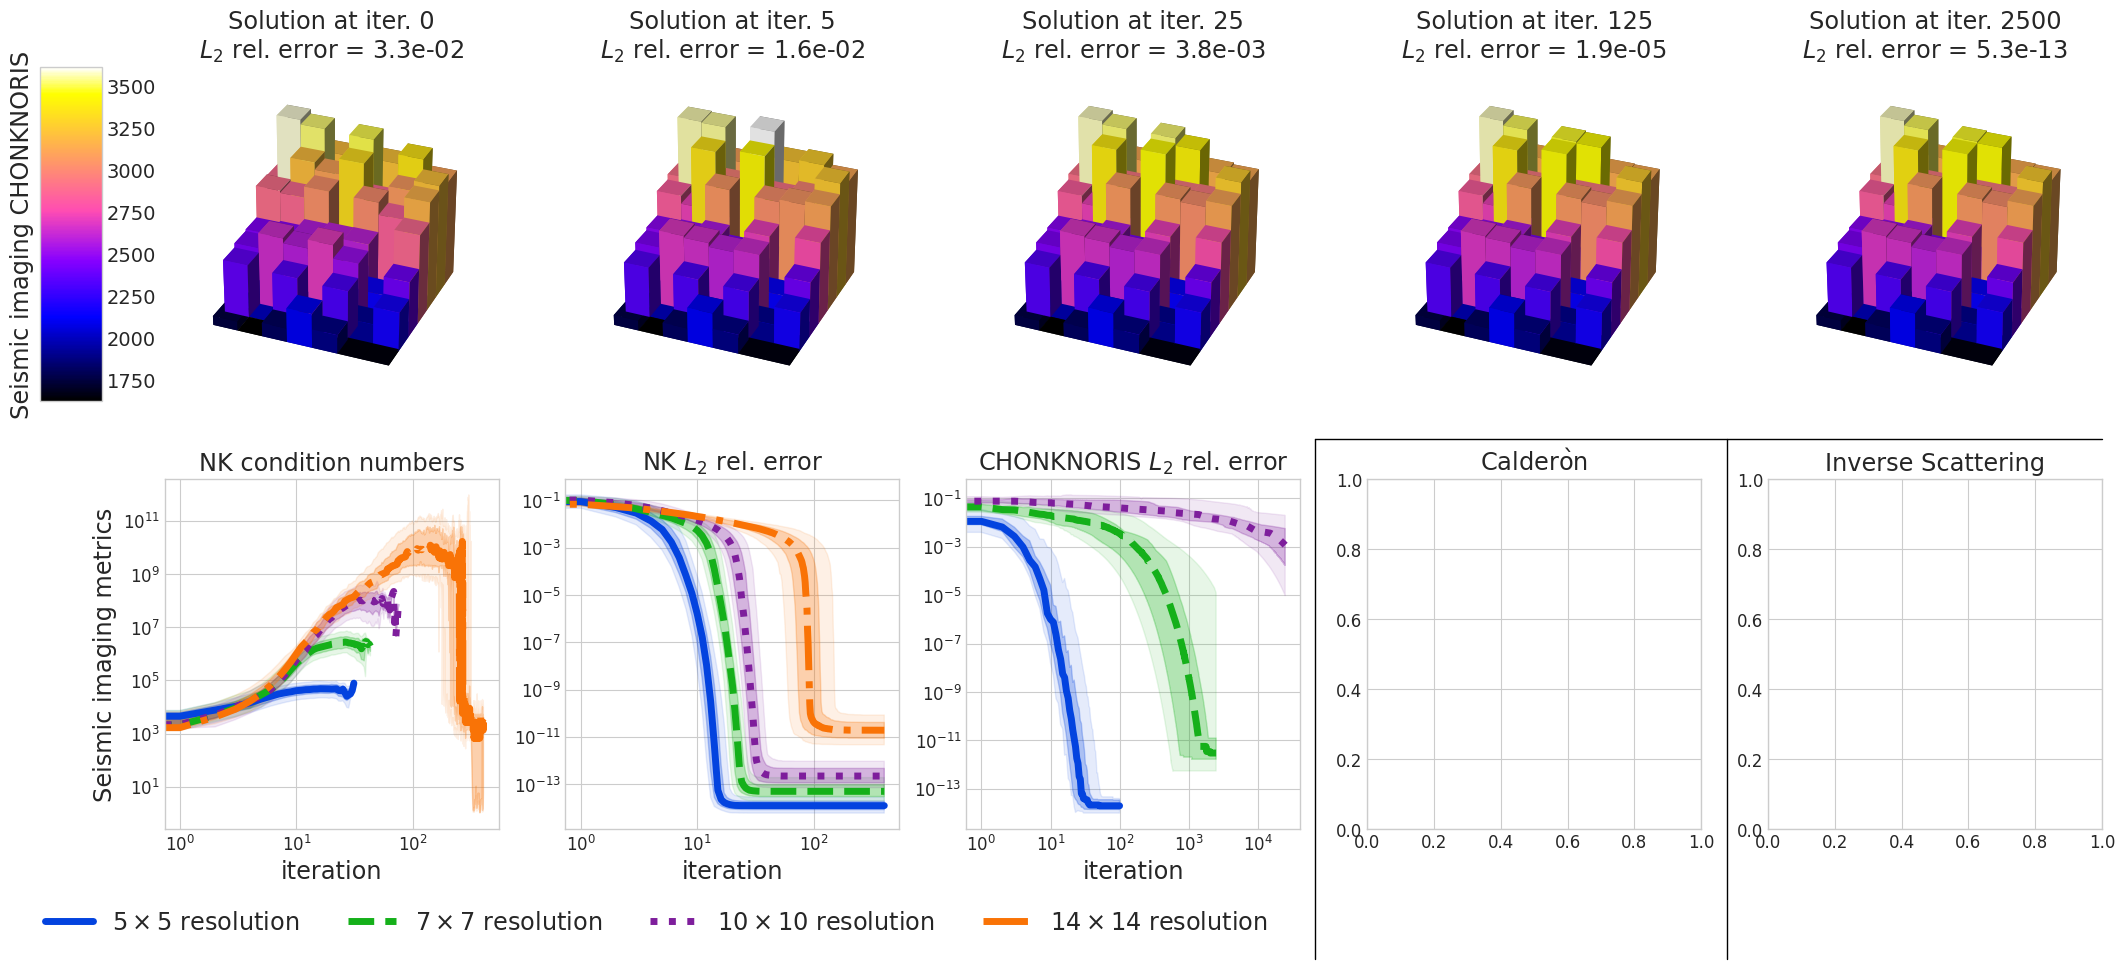

In [5]:
ncols = 5
nrows = 2 
fig = pyplot.figure(figsize=(5*ncols,5*nrows))
ax = np.array([[fig.add_subplot(nrows,ncols,i*ncols+j+1,projection=None if i==1 else "3d") for j in range(ncols)] for i in range(nrows)]).reshape((nrows,ncols))
# SEISMIC QUANTILES 
for j,name in enumerate(ds_si_ref["dskeys_ref"]):
    for l,tag in enumerate(ds_si_ref["metrics"]):
        qll,ql,qm,qh,qhh = ds_si_ref[name][tag]
        ax[1,l].plot(qm,color=COLORS[j],linewidth=lwthick,linestyle=linestyles[j],label=name)
        ax[1,l].fill_between(torch.arange(ql.size(0)),ql,qh,color=COLORS[j],alpha=alpha)
        ax[1,l].fill_between(torch.arange(qll.size(0)),qll,qhh,color=COLORS[j],alpha=alpha2)
for j,name in enumerate(ds_si_chonknoris["dskeys"]):
    qll,ql,qm,qh,qhh = ds_si_chonknoris[name]["l2rerrors"]
    ax[1,2].plot(qm,color=COLORS[j],linewidth=lwthick,linestyle=linestyles[j])
    ax[1,2].fill_between(torch.arange(ql.size(0)),ql,qh,color=COLORS[j],alpha=alpha)
    ax[1,2].fill_between(torch.arange(qll.size(0)),qll,qhh,color=COLORS[j],alpha=alpha2)
for i in range(3):
    ax[1,i].set_yscale("log",base=10)
    ax[1,i].set_xscale("log",base=10)
    ax[1,i].set_xlabel("iteration",fontsize="xx-large")
ax[1,0].set_title("NK condition numbers",fontsize="xx-large")
ax[1,1].set_title(r"NK $L_2$ rel. error",fontsize="xx-large")
ax[1,2].set_title(r"CHONKNORIS $L_2$ rel. error",fontsize="xx-large")
handles,labels = ax[1,0].get_legend_handles_labels()
fig.legend(handles[:5],labels[:5],bbox_to_anchor=(.575,.05),ncol=4,fontsize="xx-large")
ax[1,0].set_ylabel("Seismic imaging metrics",fontsize="xx-large")
# CONVERGENCE PLOT
iters = [0,5,25,125,2500]
v = vs_chonknoris[iters]
v_l2rerrors = vs_l2rerrors[iters]
vmin,vmax = v.min(),v.max()
vnorm = pyplot.Normalize(vmin=vmin,vmax=vmax)
nrows = 2 
ncols = len(iters)
i1mesh,i0mesh = torch.meshgrid(torch.arange(v[0].shape[-1]),torch.arange(v[0].shape[-1]),indexing="ij")
bar3dops = {"zsort":"min","shade":True}
for i in range(ncols):
    ax[0,i].bar3d(i0mesh.flatten(),i1mesh.flatten(),vmin,1,1,v[i].flatten()-vmin,color=cmap(vnorm(v[i].flatten())),**bar3dops)
    ax[0,i].set_title("Solution at iter. %d\n$L_2$ rel. error = %.1e"%(iters[i],v_l2rerrors[i]),fontsize="xx-large")
for i in range(ncols):
    ax[0,i].set_zlim(vmin,vmax)
    ax[0,i].view_init(None,(-45-90)/2)
    ax[0,i].set_axis_off()
    ax[0,i].grid(False)
    ax[0,i].xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax[0,i].yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax[0,i].zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax[0,i].xaxis._axinfo["grid"]['color'] =  (1,1,1,0)
    ax[0,i].yaxis._axinfo["grid"]['color'] =  (1,1,1,0)
    ax[0,i].zaxis._axinfo["grid"]['color'] =  (1,1,1,0)
cax_v = fig.add_axes([ax[0,0].get_position().x0-.05,ax[0,0].get_position().y0,0.025,ax[0,0].get_position().y1-ax[0,0].get_position().y0])
cbar_v = fig.colorbar(cm.ScalarMappable(norm=vnorm,cmap=cmap),cax_v,location="left")
cbar_v.ax.yaxis.set_ticks_position('right')
cbar_v.ax.tick_params(labelsize=14)
cbar_v.set_label("Seismic imaging CHONKNORIS",fontsize="xx-large")
# CALDERON 
ax[1,3].set_title(r"$\mathrm{Calder\`{o}n}$",fontsize="xx-large")
ax[1,4].set_title("Inverse Scattering",fontsize="xx-large")
# META 
# fig.tight_layout()
fig.add_artist(pyplot.Line2D((5.85/10,9/10),(1/2,1/2),linewidth=1,color="k"))
fig.add_artist(pyplot.Line2D((5.85/10,5.85/10),(-1/50,.5),linewidth=1,color="k"))
fig.add_artist(pyplot.Line2D((7.5/10,7.5/10),(-1/50,.5),linewidth=1,color="k"))
fig.savefig("out/inverse_problems_complete.png",bbox_inches="tight",dpi=256,transparent=True)

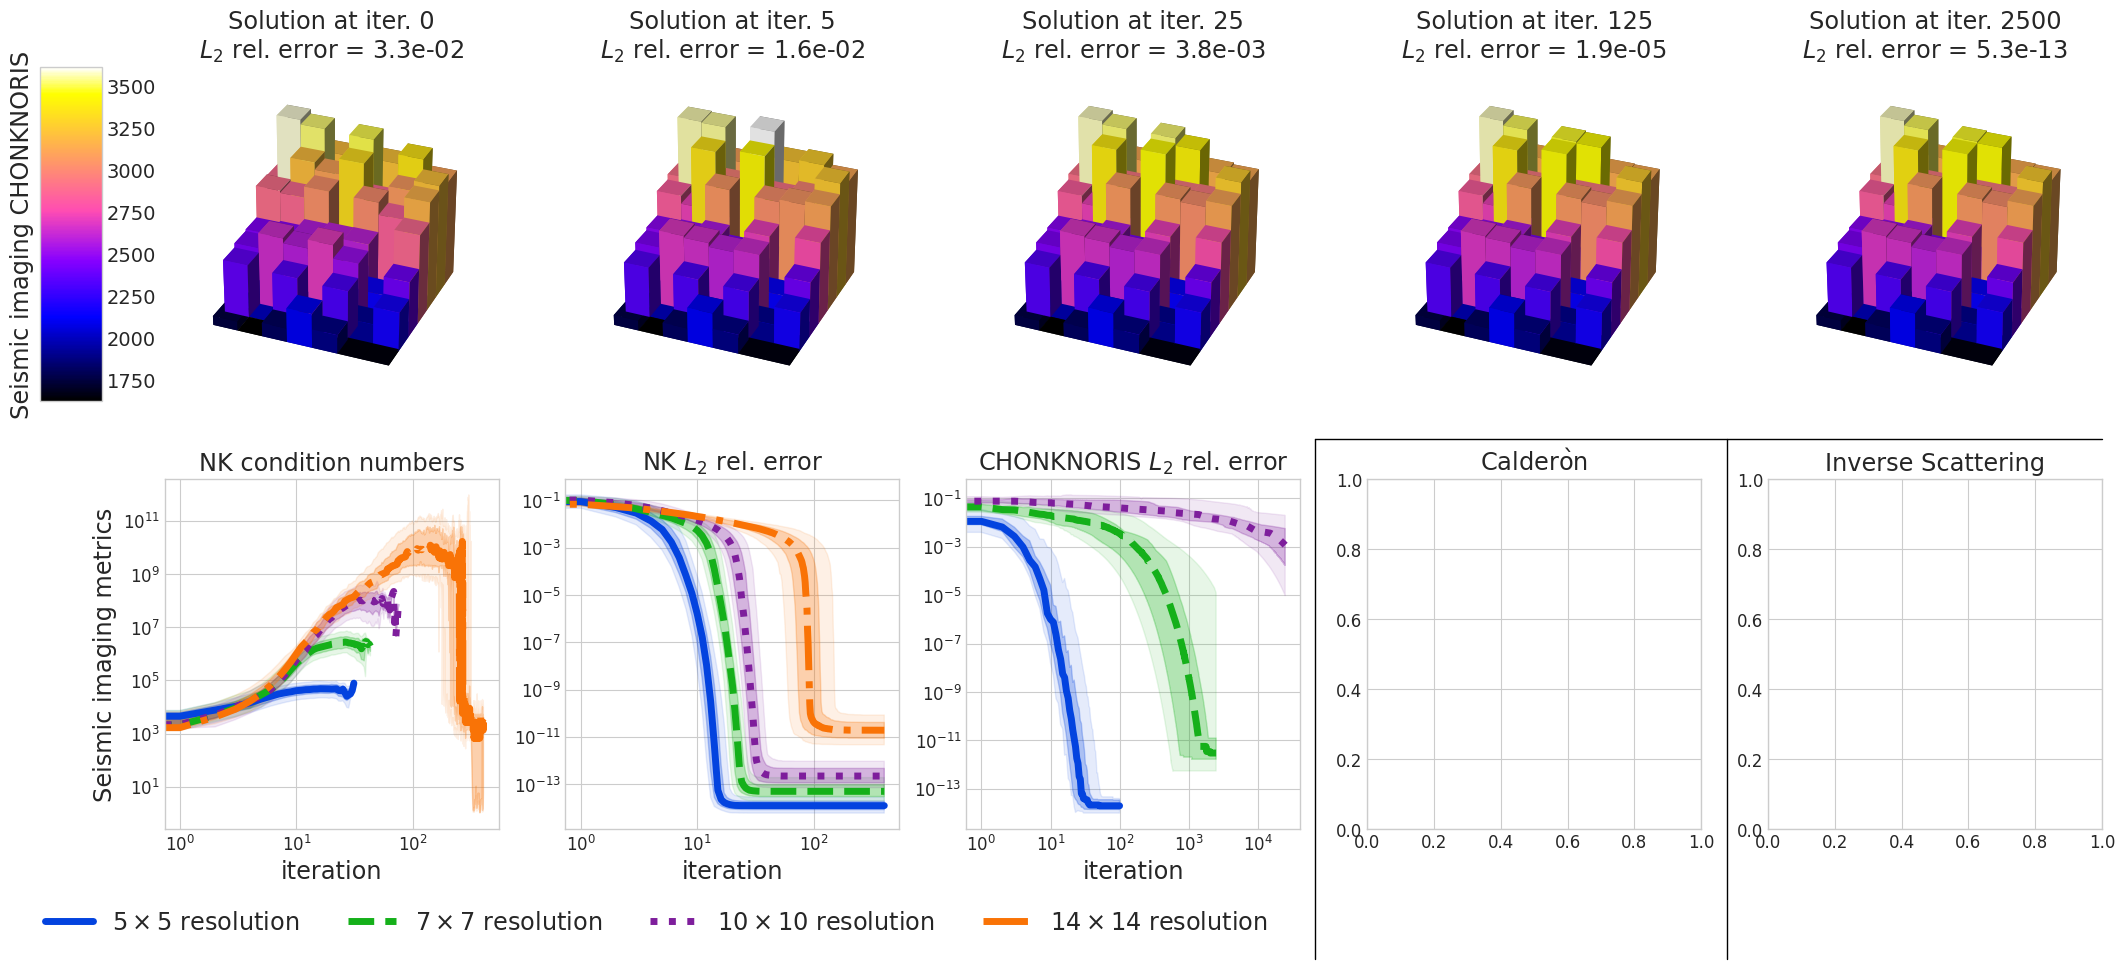

In [6]:
ncols = 5
nrows = 2 
fig = pyplot.figure(figsize=(5*ncols,5*nrows))
ax = np.array([[fig.add_subplot(nrows,ncols,i*ncols+j+1,projection=None if i==1 else "3d") for j in range(ncols)] for i in range(nrows)]).reshape((nrows,ncols))
# SEISMIC QUANTILES 
for j,name in enumerate(ds_si_ref["dskeys_ref"]):
    for l,tag in enumerate(ds_si_ref["metrics"]):
        qll,ql,qm,qh,qhh = ds_si_ref[name][tag]
        ax[1,l].plot(qm,color=COLORS[j],linewidth=lwthick,linestyle=linestyles[j],label=name)
        ax[1,l].fill_between(torch.arange(ql.size(0)),ql,qh,color=COLORS[j],alpha=alpha)
        ax[1,l].fill_between(torch.arange(qll.size(0)),qll,qhh,color=COLORS[j],alpha=alpha2)
for j,name in enumerate(ds_si_chonknoris["dskeys"]):
    qll,ql,qm,qh,qhh = ds_si_chonknoris[name]["l2rerrors"]
    ax[1,2].plot(qm,color=COLORS[j],linewidth=lwthick,linestyle=linestyles[j])
    ax[1,2].fill_between(torch.arange(ql.size(0)),ql,qh,color=COLORS[j],alpha=alpha)
    ax[1,2].fill_between(torch.arange(qll.size(0)),qll,qhh,color=COLORS[j],alpha=alpha2)
for i in range(3):
    ax[1,i].set_yscale("log",base=10)
    ax[1,i].set_xscale("log",base=10)
    ax[1,i].set_xlabel("iteration",fontsize="xx-large")
ax[1,0].set_title("NK condition numbers",fontsize="xx-large")
ax[1,1].set_title(r"NK $L_2$ rel. error",fontsize="xx-large")
ax[1,2].set_title(r"CHONKNORIS $L_2$ rel. error",fontsize="xx-large")
handles,labels = ax[1,0].get_legend_handles_labels()
fig.legend(handles[:5],labels[:5],bbox_to_anchor=(.575,.05),ncol=4,fontsize="xx-large")
ax[1,0].set_ylabel("Seismic imaging metrics",fontsize="xx-large")
# CONVERGENCE PLOT
iters = [0,5,25,125,2500]
v = vs_chonknoris[iters]
v_l2rerrors = vs_l2rerrors[iters]
vmin,vmax = v.min(),v.max()
vnorm = pyplot.Normalize(vmin=vmin,vmax=vmax)
nrows = 2 
ncols = len(iters)
i1mesh,i0mesh = torch.meshgrid(torch.arange(v[0].shape[-1]),torch.arange(v[0].shape[-1]),indexing="ij")
bar3dops = {"zsort":"min","shade":True}
for i in range(ncols):
    ax[0,i].bar3d(i0mesh.flatten(),i1mesh.flatten(),vmin,1,1,v[i].flatten()-vmin,color=cmap(vnorm(v[i].flatten())),**bar3dops)
    ax[0,i].set_title("Solution at iter. %d\n$L_2$ rel. error = %.1e"%(iters[i],v_l2rerrors[i]),fontsize="xx-large")
for i in range(ncols):
    ax[0,i].set_zlim(vmin,vmax)
    ax[0,i].view_init(None,(-45-90)/2)
    ax[0,i].set_axis_off()
    ax[0,i].grid(False)
    ax[0,i].xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax[0,i].yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax[0,i].zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax[0,i].xaxis._axinfo["grid"]['color'] =  (1,1,1,0)
    ax[0,i].yaxis._axinfo["grid"]['color'] =  (1,1,1,0)
    ax[0,i].zaxis._axinfo["grid"]['color'] =  (1,1,1,0)
cax_v = fig.add_axes([ax[0,0].get_position().x0-.05,ax[0,0].get_position().y0,0.025,ax[0,0].get_position().y1-ax[0,0].get_position().y0])
cbar_v = fig.colorbar(cm.ScalarMappable(norm=vnorm,cmap=cmap),cax_v,location="left")
cbar_v.ax.yaxis.set_ticks_position('right')
cbar_v.ax.tick_params(labelsize=14)
cbar_v.set_label("Seismic imaging CHONKNORIS",fontsize="xx-large")
# CALDERON 
ax[1,3].set_title(r"$\mathrm{Calder\`{o}n}$",fontsize="xx-large")
ax[1,4].set_title("Inverse Scattering",fontsize="xx-large")
# META 
# fig.tight_layout()
fig.add_artist(pyplot.Line2D((5.85/10,9/10),(1/2,1/2),linewidth=1,color="k"))
fig.add_artist(pyplot.Line2D((5.85/10,5.85/10),(-1/50,.5),linewidth=1,color="k"))
fig.add_artist(pyplot.Line2D((7.5/10,7.5/10),(-1/50,.5),linewidth=1,color="k"))
fig.savefig("out/inverse_problems_complete.png",bbox_inches="tight",dpi=256,transparent=True)

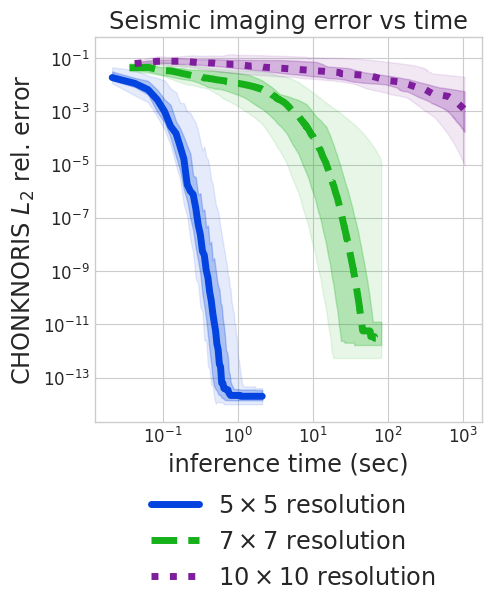

In [29]:
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(5,5)) 
# SEISMIC QUANTILES 
for j,name in enumerate(ds_si_chonknoris["dskeys"]):
    qll,ql,qm,qh,qhh = ds_si_chonknoris[name]["l2rerrors"]
    ax.plot(ds_si_chonknoris[name]["times"],qm,color=COLORS[j],linewidth=lwthick,linestyle=linestyles[j],label=name)
    ax.fill_between(ds_si_chonknoris[name]["times"],ql,qh,color=COLORS[j],alpha=alpha)
    ax.fill_between(ds_si_chonknoris[name]["times"],qll,qhh,color=COLORS[j],alpha=alpha2)
ax.set_yscale("log",base=10)
ax.set_xscale("log",base=10)
ax.set_xlabel("inference time (sec)",fontsize="xx-large")
ax.set_ylabel(r"CHONKNORIS $L_2$ rel. error",fontsize="xx-large")
handles,labels = ax.get_legend_handles_labels()
fig.legend(handles[:3],labels[:3],bbox_to_anchor=(.85,.01),ncol=1,fontsize="xx-large")
ax.set_title("Seismic imaging error vs time",fontsize="xx-large");
fig.savefig("out/fwi_errors_vs_times.png",bbox_inches="tight",dpi=256,transparent=True)